# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [1]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [2]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))


<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   continent  1704 non-null   str    
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   str    
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 106.6 KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: <StringArray>
['Asia', 'Europe', 'Africa', 'Americas', 'Oceania']
Length: 5, dtype: str
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.

## Task 1 — Scatter: life expectancy change over time

**What to build:** A scatter showing **GDP per capita vs life expectancy** for **two years** (2000 and 2007) to show how both moved — use **colour for year** (just 2 colours), **one continent only**.

Choose any continent except Africa (that was the example). Highlight the change direction.

> 💡 Filter: `df.loc[df['continent'] == 'YOUR_CHOICE']` then filter years


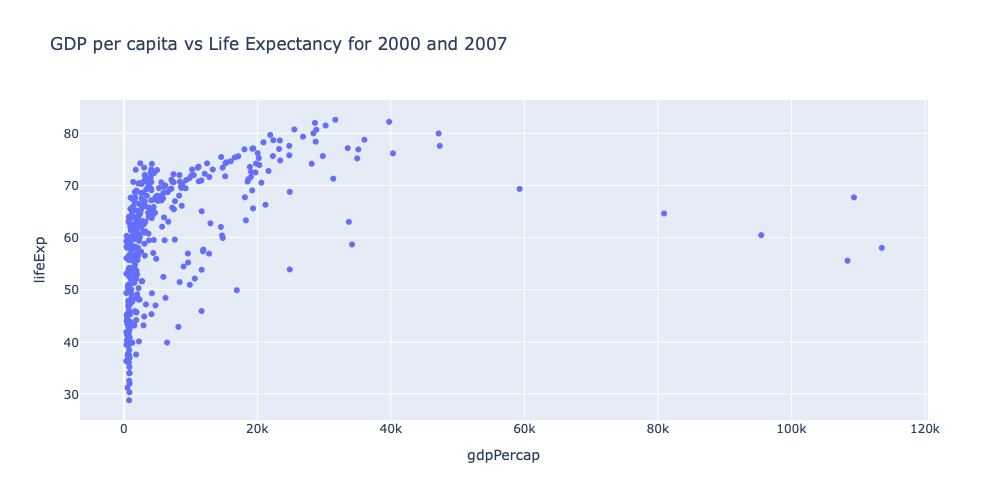

In [11]:
# Task 1
# YOUR CODE HERE

fig = px.scatter(df.loc[df['continent'] == 'Asia'], x='gdpPercap', y='lifeExp',
                 title='GDP per capita vs Life Expectancy for 2000 and 2007', height=500)
fig.show()


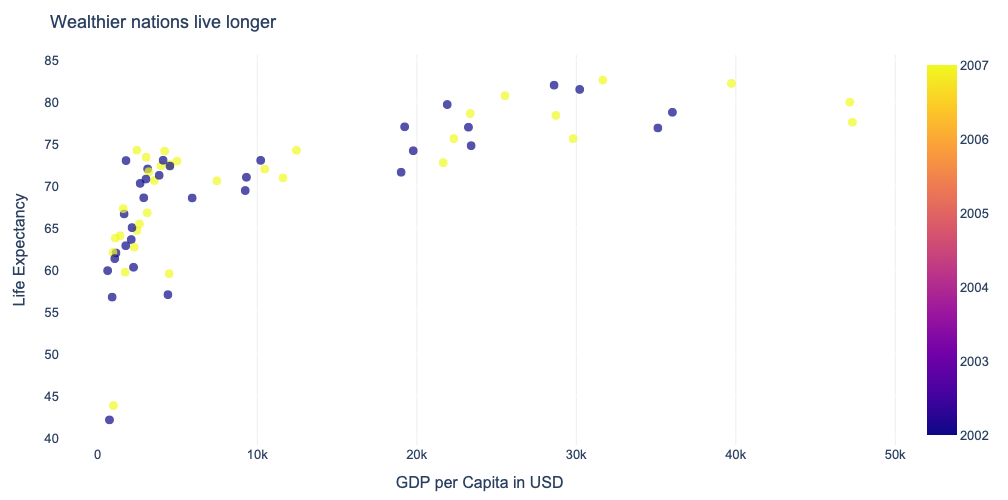

In [45]:
fig = px.scatter(
    data_frame=df.loc[(df['continent'] == 'Asia') & (df['year'].isin([2002, 2007]))], x='gdpPercap', y='lifeExp',
    color='year',                    # colour encodes category (continent)
    hover_name='country',                   # hover shows country name
    labels={'gdpPercap': 'GDP per Capita in USD',
            'lifeExp': 'Life Expectancy',
            'year': ''},
    color_discrete_sequence=px.colors.qualitative.Bold  # plotly express 
)
fig.update_layout(
    title='Wealthier nations live longer',
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    xaxis=dict(showgrid=True, gridcolor='#EEEEEE'),
    margin=dict(l=60, r=40, t=55, b=40), height=500
)

fig.update_traces(marker=dict(size=9, opacity=0.7))
fig.show()

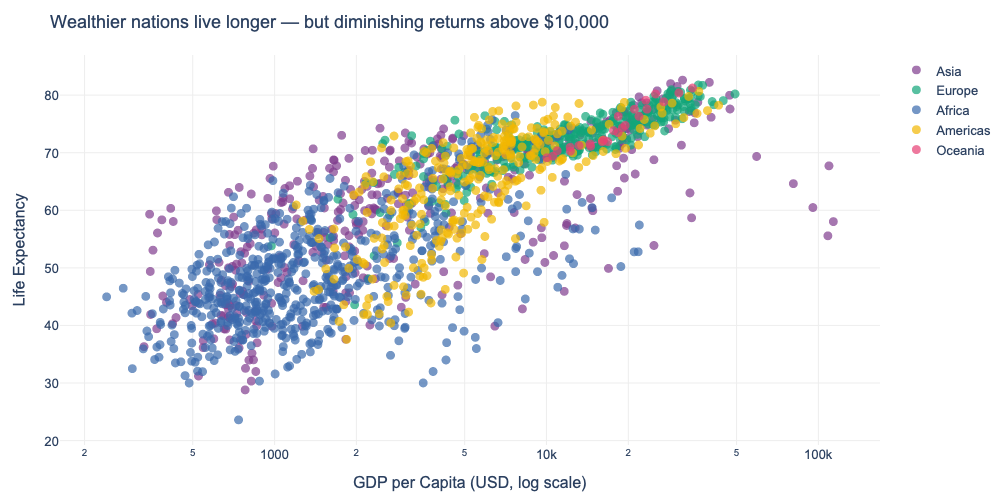

In [35]:
fig = px.scatter(
    data_frame=df, x='gdpPercap', y='lifeExp',
    color='continent',                     
    hover_name='country',                 
    log_x=True,                             # log scale: wealth is non-linear
    labels={'gdpPercap': 'GDP per Capita (USD, log scale)',
            'lifeExp': 'Life Expectancy',
            'continent': ''},
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_layout(
    title='Wealthier nations live longer — but diminishing returns above $10,000',
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    yaxis=dict(gridcolor='#EEEEEE'),
    xaxis=dict(showgrid=True, gridcolor='#EEEEEE'),
    margin=dict(l=60, r=40, t=55, b=40), height=500
)
fig.update_traces(marker=dict(size=9, opacity=0.7))
fig.show()

## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


In [ ]:
# Task 2
# YOUR CODE HERE
